In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [2]:
#from google.colab import files
#uploaded = files.upload()

# Library Setup  #
This code imports all the necessary libraries required for data analysis and visualization. It uses NumPy and Pandas for handling data, Matplotlib and Seaborn for plotting graphs, and sklearn tools for data preprocessing

In [3]:
df = pd.read_excel('World_development_mesurement.xlsx')
df.head()

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,...,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,...,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,...,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,...,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,...,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"


# Data Import #
This code loads the dataset from an Excel file into a DataFrame using Pandas. After loading, it displays the dataset so we can view and understand the data. This step helps in checking the structure and contents of the dataset.

DATA PREPROCESSING

In [4]:
df.shape

(2704, 25)

# Dataset Dimensions #
Used  to check the number of rows and columns in the dataset.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2585 non-null   float64
 1   Business Tax Rate       1423 non-null   object 
 2   CO2 Emissions           2125 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  1718 non-null   float64
 5   Ease of Business        185 non-null    float64
 6   Energy Usage            1785 non-null   float64
 7   GDP                     2494 non-null   object 
 8   Health Exp % GDP        2395 non-null   float64
 9   Health Exp/Capita       2395 non-null   object 
 10  Hours to do Tax         1416 non-null   float64
 11  Infant Mortality Rate   2444 non-null   float64
 12  Internet Usage          2531 non-null   float64
 13  Lending Interest        1880 non-null   float64
 14  Life Expectancy Female  2568 non-null   

# Dataset Info #
This code provides a summary of the dataset, including column names, data types, and non-null values.
It helps in understanding the structure of the data and identifying missing values. This step is useful for data cleaning and preprocessing.

In [6]:
df.columns

Index(['Birth Rate', 'Business Tax Rate', 'CO2 Emissions', 'Country',
       'Days to Start Business', 'Ease of Business', 'Energy Usage', 'GDP',
       'Health Exp % GDP', 'Health Exp/Capita', 'Hours to do Tax',
       'Infant Mortality Rate', 'Internet Usage', 'Lending Interest',
       'Life Expectancy Female', 'Life Expectancy Male', 'Mobile Phone Usage',
       'Number of Records', 'Population 0-14', 'Population 15-64',
       'Population 65+', 'Population Total', 'Population Urban',
       'Tourism Inbound', 'Tourism Outbound'],
      dtype='object')

# Column Names #
This line displays the names of all the columns in the dataset.
It helps us understand what features are available for analysis.
This is useful when selecting or working with specific columns.

In [7]:
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
Birth Rate,2585.000000,0.022715,0.011338,0.007000,0.013000,0.020000,0.031000,0.053000
CO2 Emissions,2125.000000,142307.107765,615928.805709,7.000000,1360.000000,8529.000000,59108.000000,8286892.000000
Days to Start Business,1718.000000,39.999418,57.318588,1.000000,13.000000,26.000000,45.000000,694.000000
Ease of Business,185.000000,94.875676,54.791906,1.000000,48.000000,94.000000,142.000000,189.000000
Energy Usage,1785.000000,77236.840896,259923.855845,8.000000,3737.000000,14338.000000,41852.000000,2727728.000000
Health Exp % GDP,2395.000000,0.064170,0.026325,0.008000,0.046000,0.061000,0.079000,0.225000
Hours to do Tax,1416.000000,302.068503,273.299686,12.000000,156.000000,239.000000,344.750000,2600.000000
Infant Mortality Rate,2444.000000,0.032813,0.029968,0.002000,0.009000,0.020000,0.053000,0.141000
Internet Usage,2531.000000,0.239747,0.260132,0.000000,0.000000,0.100000,0.400000,1.000000
Lending Interest,1880.000000,0.148103,0.171829,0.005000,0.080000,0.120000,0.173000,4.965000


# Statistical Summary #
This code generates statistical summary of the dataset like mean, min, max, and standard deviation for each column.
The transpose (.T) makes it easier to read, and the background gradient adds color for better visualization.
This helps in quickly understanding the distribution of the data.


HANDLING MISSING VALUES

In [8]:
df.isnull().sum()

Birth Rate                 119
Business Tax Rate         1281
CO2 Emissions              579
Country                      0
Days to Start Business     986
Ease of Business          2519
Energy Usage               919
GDP                        210
Health Exp % GDP           309
Health Exp/Capita          309
Hours to do Tax           1288
Infant Mortality Rate      260
Internet Usage             173
Lending Interest           824
Life Expectancy Female     136
Life Expectancy Male       136
Mobile Phone Usage         167
Number of Records            0
Population 0-14            220
Population 15-64           220
Population 65+             220
Population Total             0
Population Urban            26
Tourism Inbound            368
Tourism Outbound           471
dtype: int64

# Null Value Count #
This line checks for missing values in each column of the dataset.
It returns the total count of null values present in every column.
This helps in identifying which columns need data cleaning.

FILLIED MISSING VALUES

In [9]:
# Identify numerical columns with missing values
numerical_cols_with_nan = df.select_dtypes(include=np.number).columns[df.select_dtypes(include=np.number).isnull().any()].tolist()

# Impute numerical columns with median
for col in numerical_cols_with_nan:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

# Identify object columns with missing values
object_cols_with_nan = df.select_dtypes(include='object').columns[df.select_dtypes(include='object').isnull().any()].tolist()

# Define a cleaning function for currency/percentage like strings
def clean_and_convert_to_numeric(series):
    # Remove '$', ',', '%' and convert to numeric, handling errors
    cleaned_series = series.astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.replace('%', '', regex=False)
    return pd.to_numeric(cleaned_series, errors='coerce')

# Process object columns
for col in object_cols_with_nan:
    # Clean and convert to numeric
    df[col] = clean_and_convert_to_numeric(df[col])
    # Impute the new numeric column with its median
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

# Verify no more missing values
print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
Birth Rate                0
Business Tax Rate         0
CO2 Emissions             0
Country                   0
Days to Start Business    0
Ease of Business          0
Energy Usage              0
GDP                       0
Health Exp % GDP          0
Health Exp/Capita         0
Hours to do Tax           0
Infant Mortality Rate     0
Internet Usage            0
Lending Interest          0
Life Expectancy Female    0
Life Expectancy Male      0
Mobile Phone Usage        0
Number of Records         0
Population 0-14           0
Population 15-64          0
Population 65+            0
Population Total          0
Population Urban          0
Tourism Inbound           0
Tourism Outbound          0
dtype: int64


CHECK DUPLICATES

In [10]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2699    False
2700    False
2701    False
2702    False
2703    False
Length: 2704, dtype: bool

# Duplicate Rows Check #
This line checks for duplicate rows in the dataset.
It returns True or False for each row depending on whether it is duplicated or not.
This helps in identifying repeated data that may need to be removed.

Clean Currency Columns

Columns like Tourism Inbound contain $ and ,.

In [11]:
df['Tourism Inbound'] = df['Tourism Inbound'].replace('[\$,]', '', regex=True).astype(float)
df['Tourism Outbound'] = df['Tourism Outbound'].replace('[\$,]', '', regex=True).astype(float)

# Currency Cleaning & Conversion #
This code cleans the Tourism Inbound and Tourism Outbound columns by removing symbols like `$` and commas. After that, it converts the values into float type for proper numerical analysis.
This step ensures the data is ready for calculations and modeling.


Handle Categorical Data

Country is categorical.

In [12]:
df['Country'] = df['Country'].astype('category')

# Categorical Conversion #
Converted the Country column to categorical type for efficient storage and easier categorical analysis.

OUTLIER Detection

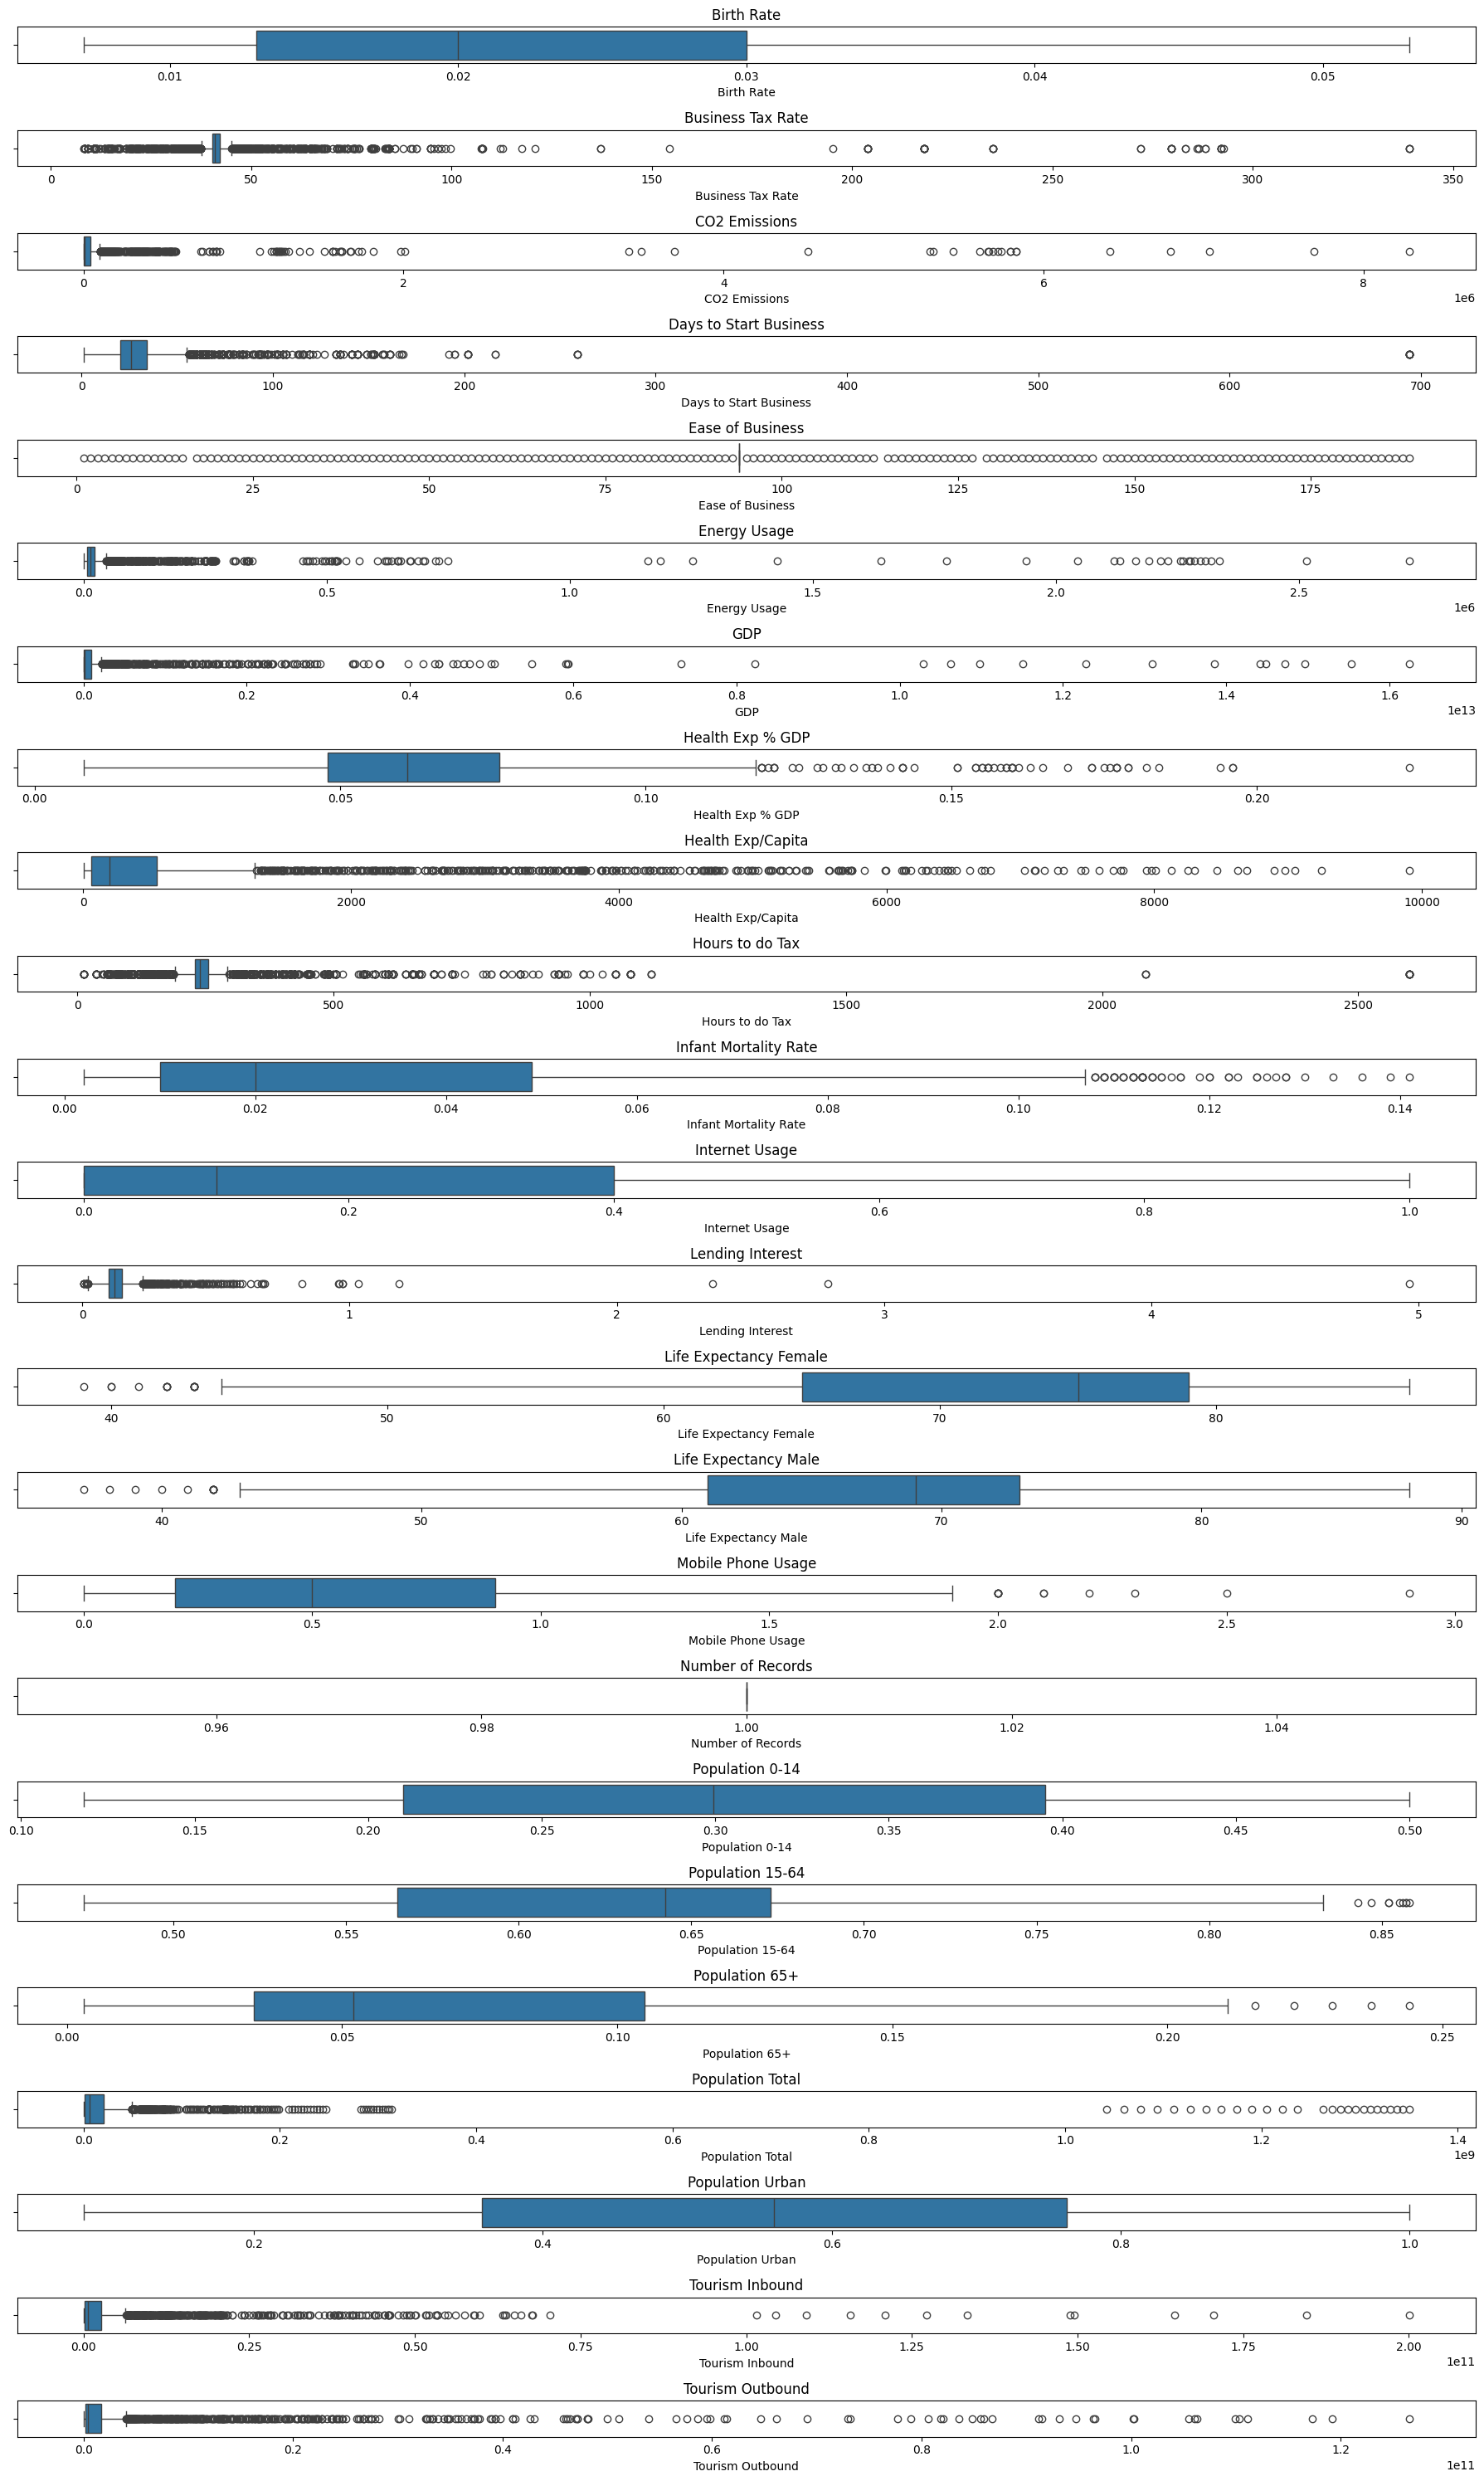

In [13]:
num_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(18,30))
for i, col in enumerate(num_cols):
     plt.subplot(len(num_cols), 1, i+1)
     sns.boxplot(x=df[col])
     plt.title(col)
plt.tight_layout()
plt.show()

# Outlier Visualization #
Plotted boxplots for all numeric columns to visually detect outliers and distribution patterns across features

In [14]:
num_df = df.select_dtypes(include=np.number)
Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = ((num_df < lower_limit) | (num_df > upper_limit))
print(outliers.sum())

Birth Rate                   0
Business Tax Rate         1130
CO2 Emissions              387
Days to Start Business     340
Ease of Business           184
Energy Usage               424
GDP                        414
Health Exp % GDP            58
Health Exp/Capita          412
Hours to do Tax            980
Infant Mortality Rate       49
Internet Usage               0
Lending Interest           245
Life Expectancy Female      14
Life Expectancy Male        11
Mobile Phone Usage          11
Number of Records            0
Population 0-14              0
Population 15-64             9
Population 65+               5
Population Total           318
Population Urban             0
Tourism Inbound            409
Tourism Outbound           461
dtype: int64


# Outlier Detection #
Calculated Q1, Q3, and IQR for numeric columns, then flagged values outside 1.5×IQR as outliers and counted them per column.

In [15]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

# Outlier Capping #
Applied the IQR rule to numeric columns and replaced extreme values with lower/upper bounds to reduce outlier impact.

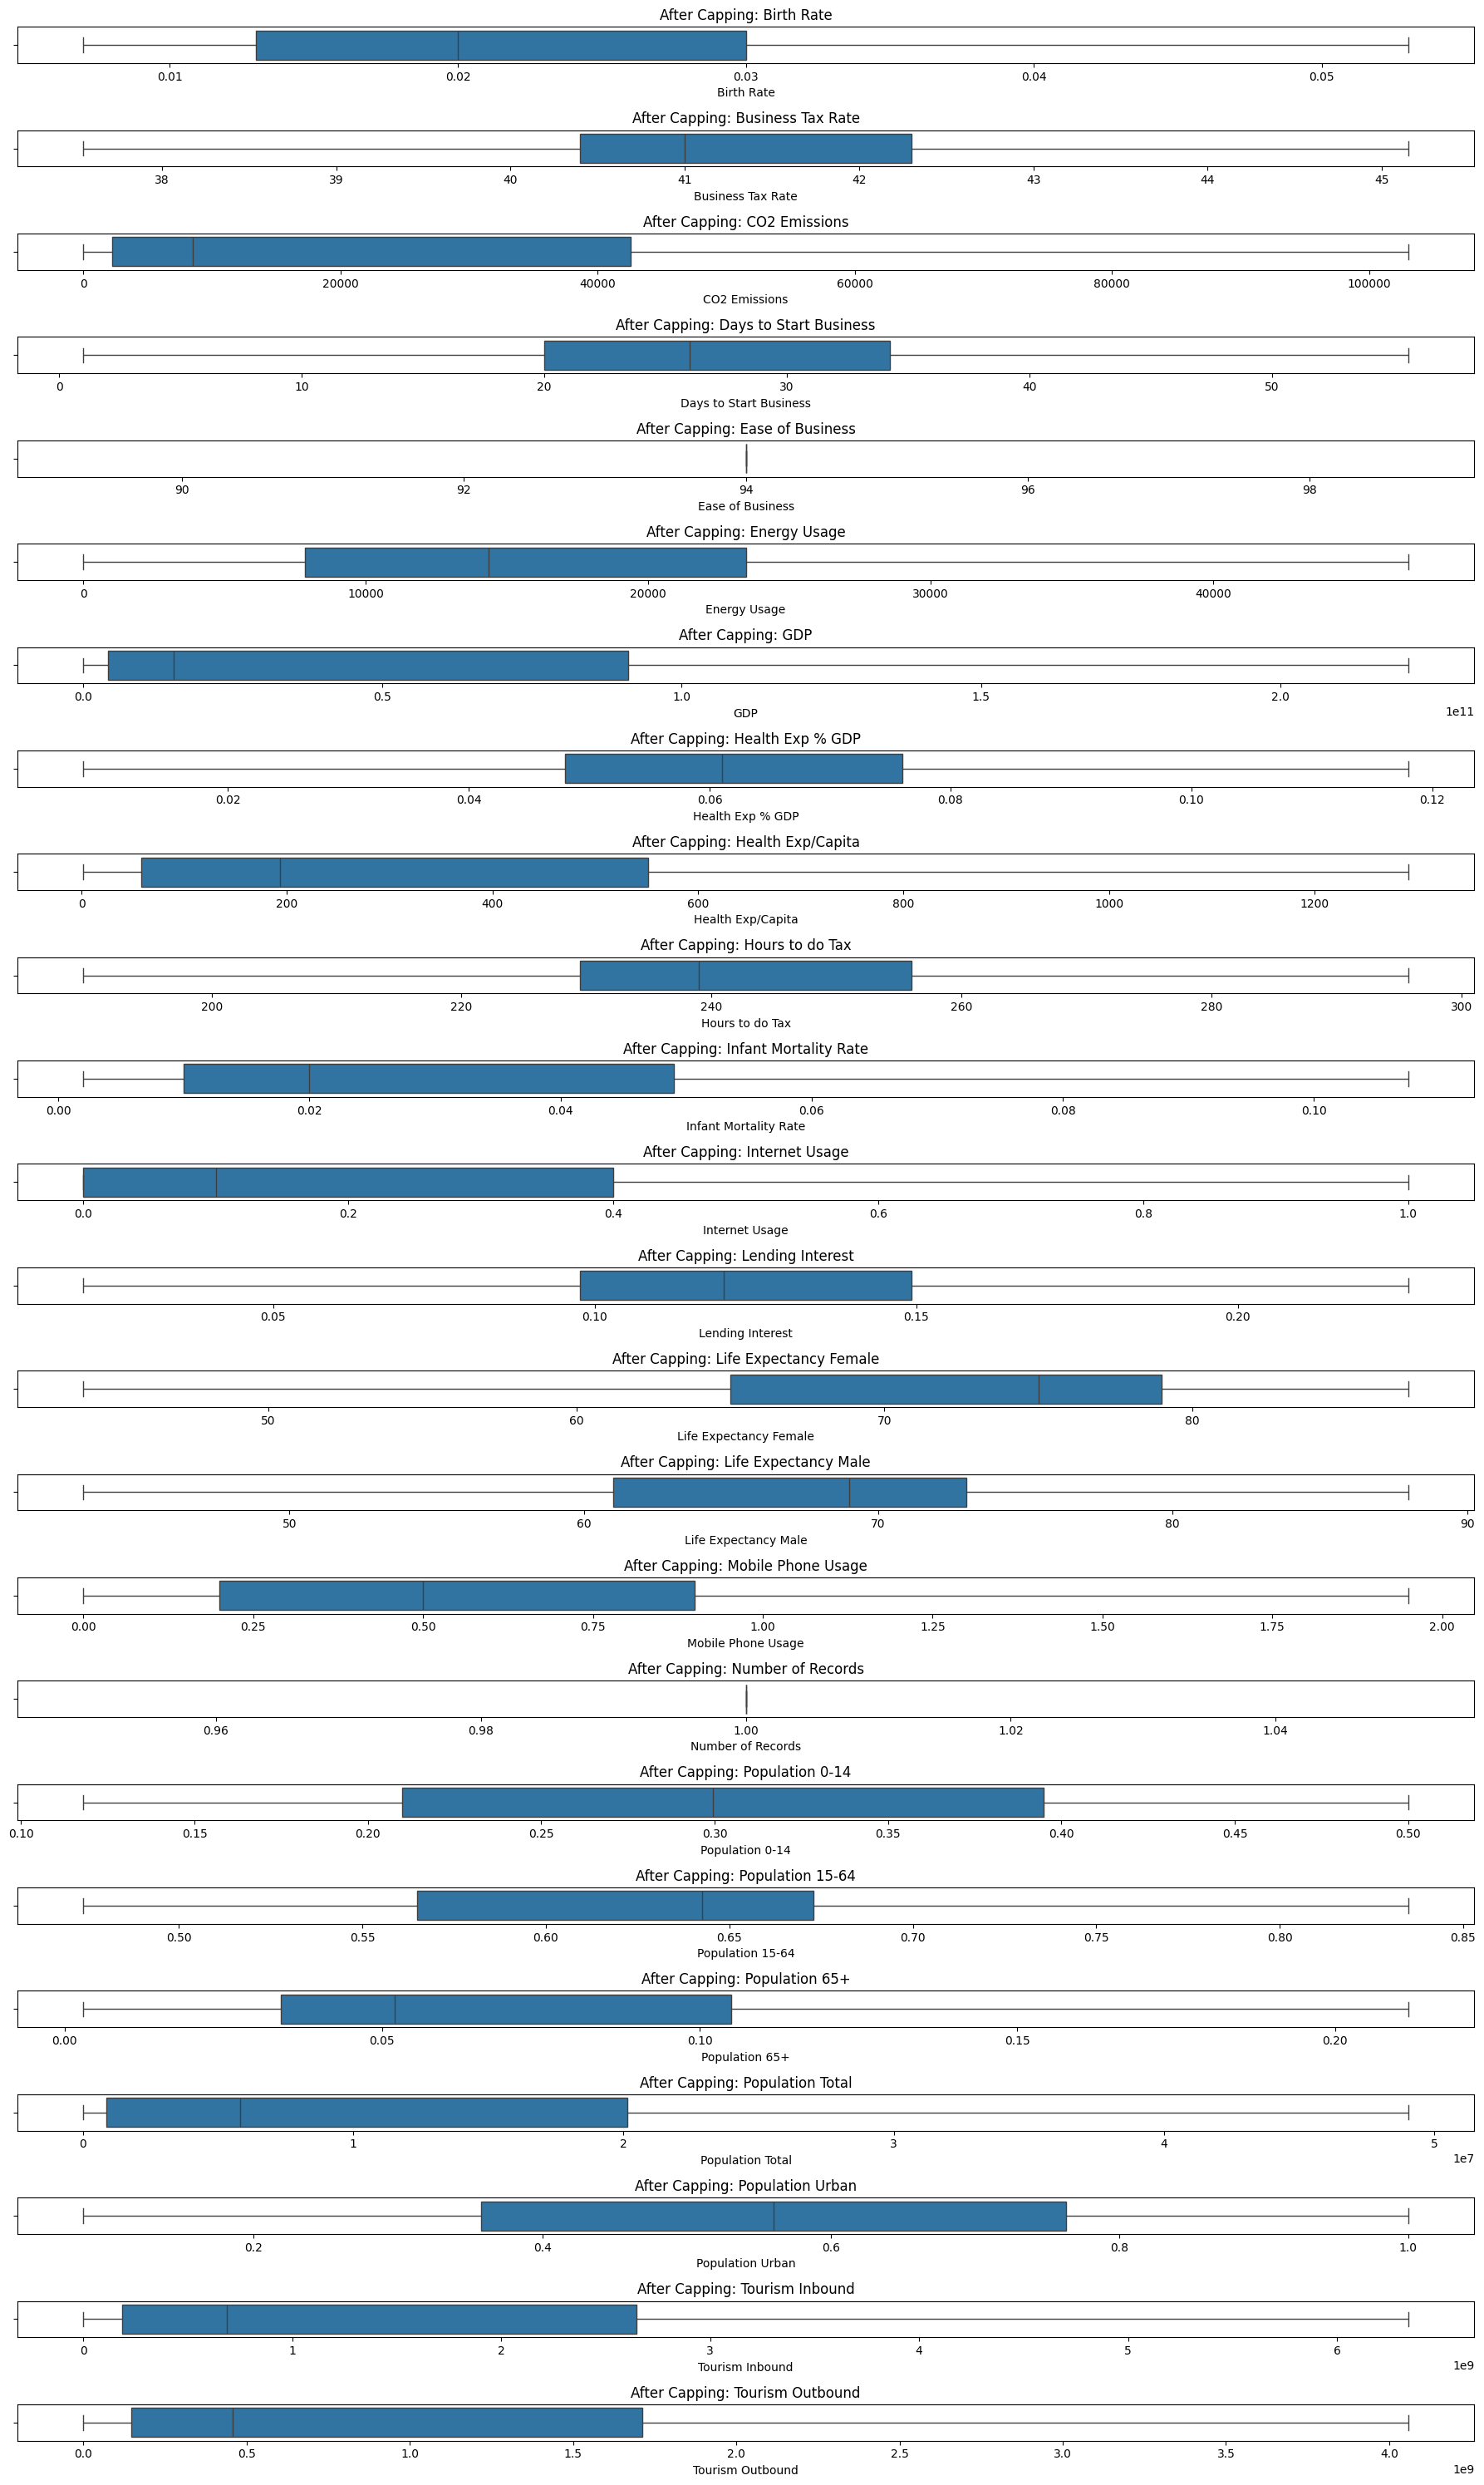

In [16]:
plt.figure(figsize=(18,30))
for i, col in enumerate(num_cols):
    plt.subplot(len(num_cols),1,i+1)
    sns.boxplot(x=df[col])
    plt.title("After Capping: " + col)
plt.tight_layout()
plt.show()

# Post-Capping Outlier Visualization #
Plotted boxplots for all numeric columns after capping extreme values, to confirm reduced outlier impact.

Feature Scaling

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols] = scaler.fit_transform(df[num_cols])

# Feature Scaling #
Applied StandardScaler to all numeric columns, standardizing values to zero mean and unit variance for balanced model input.

In [18]:
df.head(10)

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,-0.233864,-0.064792,1.659733,Algeria,-0.151075,0.0,0.590969,-0.060055,-1.266291,-0.746454,...,0.043864,-1.253652,0.0,0.384182,-0.089411,-0.684821,1.090800,0.147449,-0.754222,-0.670804
1,2.469335,-0.064792,-0.486142,Angola,-0.151075,0.0,-0.729010,-0.620533,-1.311467,-0.831569,...,-2.472735,-1.253652,0.0,1.696192,-1.886942,-0.978160,0.021270,-0.976530,-0.783976,-0.702383
2,1.838589,-0.064792,-0.703087,Benin,-0.151075,0.0,-1.102414,-0.703641,-0.904880,-0.847248,...,-1.487979,-1.253652,0.0,1.480788,-1.617312,-0.894348,-0.397993,-0.735385,-0.765161,-0.766886
3,0.396882,-0.064792,-0.630298,Botswana,-0.151075,0.0,-1.112365,-0.661547,-0.724175,-0.540387,...,-1.925648,-1.034604,0.0,0.785618,-0.568753,-0.894348,-0.710175,-0.126393,-0.699527,-0.660053
4,2.108909,-0.064792,-0.718855,Burkina Faso,-0.151075,0.0,-0.266046,-0.700549,-0.543469,-0.853967,...,-1.925648,-1.253652,0.0,1.617863,-1.797065,-0.915301,-0.117991,-1.573260,-0.788789,-0.780324
5,1.748482,-0.064792,-0.739112,Burundi,-0.151075,0.0,-0.266046,-0.721913,-0.001353,-0.865167,...,-2.144483,-1.253652,0.0,1.833268,-2.156572,-0.894348,-0.414526,-1.965631,-0.798241,-0.791075
6,1.658376,-0.064792,-0.653402,Cameroon,-0.151075,0.0,-0.809499,-0.618597,-0.859704,-0.822609,...,-1.706813,-1.253652,0.0,1.470997,-1.677230,-0.789585,0.141646,-0.441107,-0.741095,-0.638552
7,1.478162,-0.064792,-0.740015,Central African Republic,-0.151075,0.0,-0.266046,-0.721373,-0.904880,-0.856207,...,-2.582152,-1.253652,0.0,1.177263,-1.317724,-0.663868,-0.597002,-0.763996,-0.796665,-0.778308
8,2.559442,-0.064792,-0.742534,Chad,-0.151075,0.0,-0.266046,-0.715597,-0.001353,-0.858447,...,-2.253900,-1.253652,0.0,1.833268,-2.141592,-0.915301,-0.316744,-1.417947,-0.792727,-0.762855
9,1.478162,-0.064792,-0.745052,Comoros,-0.151075,0.0,-0.266046,-0.730120,-1.266291,-0.851728,...,-1.159727,-0.158413,0.0,1.098934,-1.063074,-0.852443,-0.783927,-1.152279,-0.792290,-0.494092


# Preview Data #
Displayed the first 10 rows of the DataFrame using df.head(10) to quickly inspect sample records after preprocessing.

# Inspect cleaned dataset

In [19]:
df.head()

,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,-0.233864,-0.064792,1.659733,Algeria,-0.151075,0.0,0.590969,-0.060055,-1.266291,-0.746454,...,0.043864,-1.253652,0.0,0.384182,-0.089411,-0.684821,1.090800,0.147449,-0.754222,-0.670804
1,2.469335,-0.064792,-0.486142,Angola,-0.151075,0.0,-0.729010,-0.620533,-1.311467,-0.831569,...,-2.472735,-1.253652,0.0,1.696192,-1.886942,-0.978160,0.021270,-0.976530,-0.783976,-0.702383
2,1.838589,-0.064792,-0.703087,Benin,-0.151075,0.0,-1.102414,-0.703641,-0.904880,-0.847248,...,-1.487979,-1.253652,0.0,1.480788,-1.617312,-0.894348,-0.397993,-0.735385,-0.765161,-0.766886
3,0.396882,-0.064792,-0.630298,Botswana,-0.151075,0.0,-1.112365,-0.661547,-0.724175,-0.540387,...,-1.925648,-1.034604,0.0,0.785618,-0.568753,-0.894348,-0.710175,-0.126393,-0.699527,-0.660053
4,2.108909,-0.064792,-0.718855,Burkina Faso,-0.151075,0.0,-0.266046,-0.700549,-0.543469,-0.853967,...,-1.925648,-1.253652,0.0,1.617863,-1.797065,-0.915301,-0.117991,-1.573260,-0.788789,-0.780324


# Final Data Preview #
Displayed the first 5 rows of the DataFrame using  to inspect sample records after all preprocessing steps

In [20]:
df.columns

Index(['Birth Rate', 'Business Tax Rate', 'CO2 Emissions', 'Country',
       'Days to Start Business', 'Ease of Business', 'Energy Usage', 'GDP',
       'Health Exp % GDP', 'Health Exp/Capita', 'Hours to do Tax',
       'Infant Mortality Rate', 'Internet Usage', 'Lending Interest',
       'Life Expectancy Female', 'Life Expectancy Male', 'Mobile Phone Usage',
       'Number of Records', 'Population 0-14', 'Population 15-64',
       'Population 65+', 'Population Total', 'Population Urban',
       'Tourism Inbound', 'Tourism Outbound'],
      dtype='object')

# Column Names #
Used  to list all column headers in the dataset, providing a quick overview of available features.

In [21]:
df.shape

(2704, 25)

# Dataset Shape #
Checked the shape of the DataFrame using  to view the number of rows and columns.

2704 countries/records

25 development indicators

# **Visualization**

# Correlation Heatmap

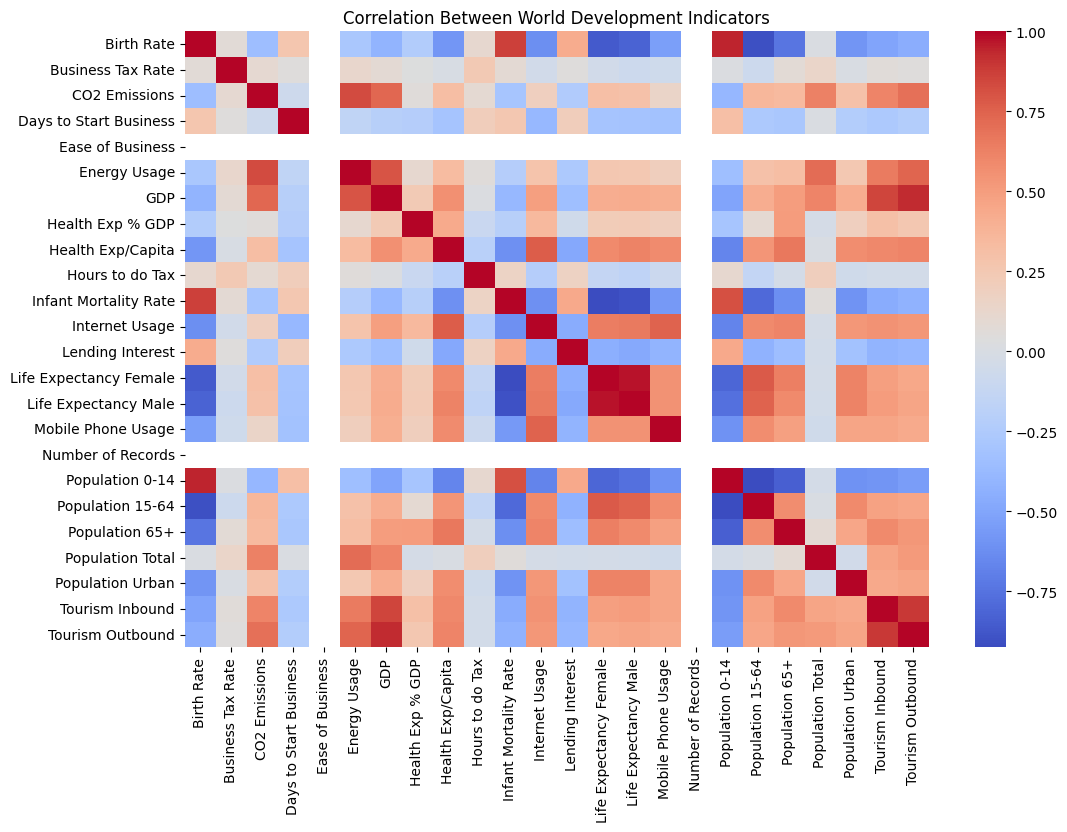

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm")

plt.title("Correlation Between World Development Indicators")

plt.show()

# Correlation Heatmap #
Computed pairwise correlations among numeric columns and visualized them with a
heatmap to highlight relationships between world development indicators.

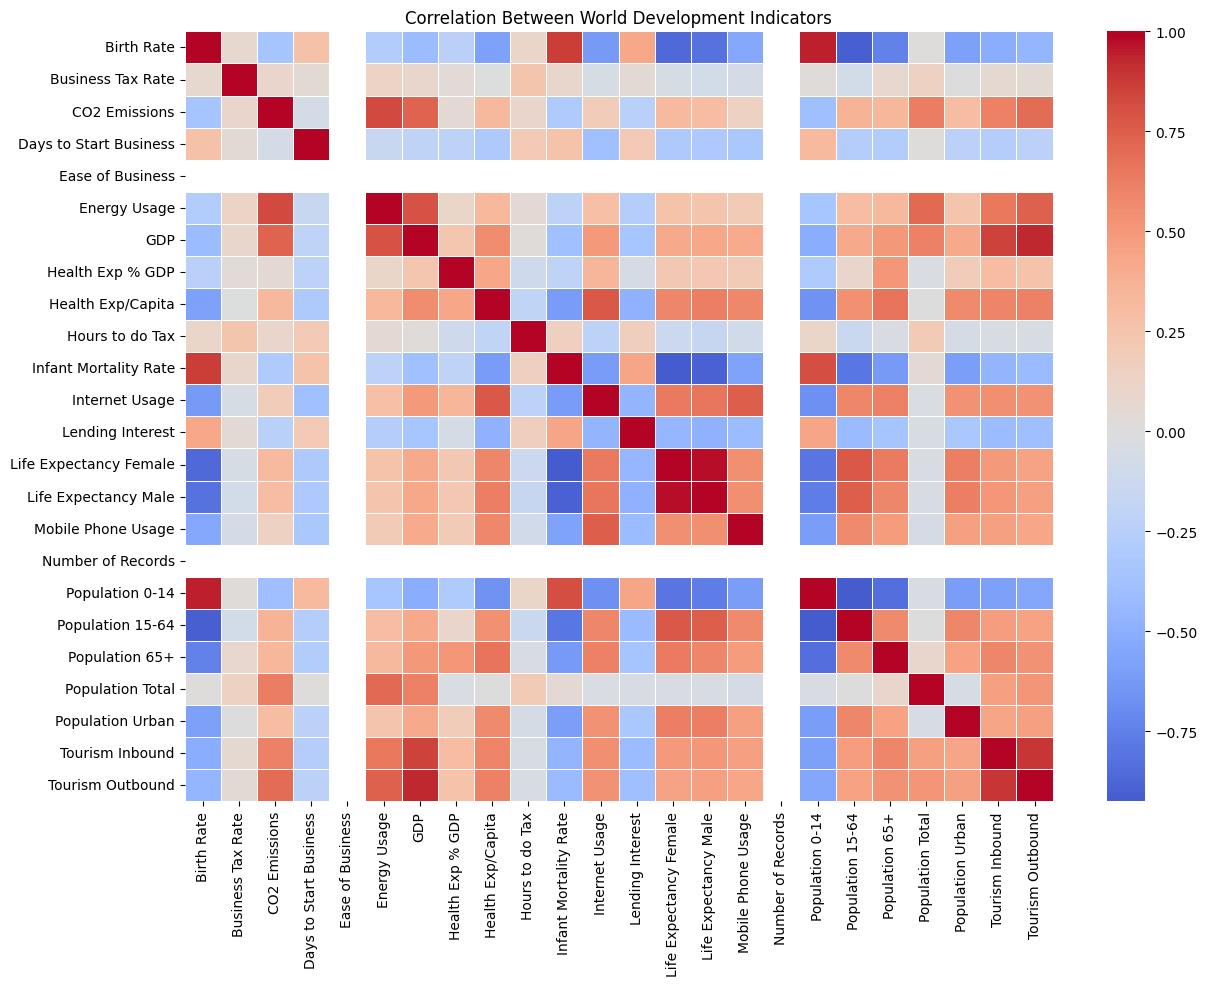

In [23]:
plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            cmap="coolwarm",
            center=0,
            linewidths=0.5)

plt.title("Correlation Between World Development Indicators")

plt.show()

# Enhanced Correlation Heatmap #
Visualized correlations among numeric columns with a centered heatmap, using linewidths for clearer separation of indicators.

The correlation heatmap visualizes relationships between global development indicators. Positive correlations can be observed between GDP, internet usage, and energy consumption, indicating that economically developed countries tend to have higher technological adoption and energy demand. Life expectancy also shows positive association with GDP and healthcare expenditure, while infant mortality rate shows negative correlation with life expectancy.

# GDP Distribution

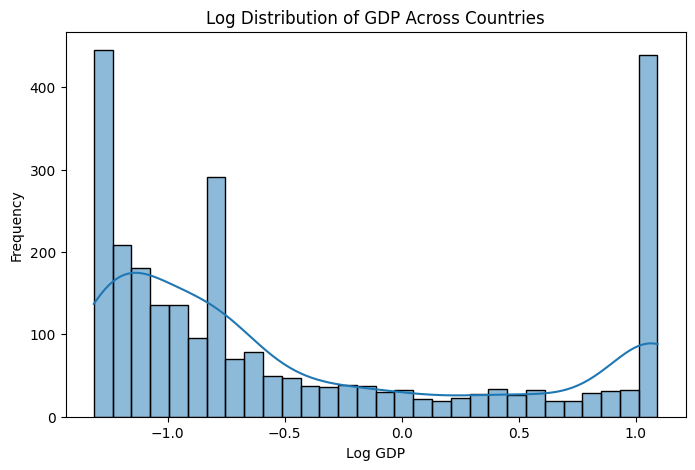

In [24]:
import numpy as np

plt.figure(figsize=(8,5))

sns.histplot(np.log1p(df["GDP"]), bins=30, kde=True)

plt.title("Log Distribution of GDP Across Countries")

plt.xlabel("Log GDP")

plt.ylabel("Frequency")

plt.show()

# Log Transformation & Distribution Plot #
Applied  to GDP values and plotted a histogram with KDE to visualize normalized distribution across countries

This histogram shows the distribution of GDP across countries. It helps understand how economic output varies globally and identifies whether most countries fall into lower or higher GDP ranges.

# Internet Usage vs GDP

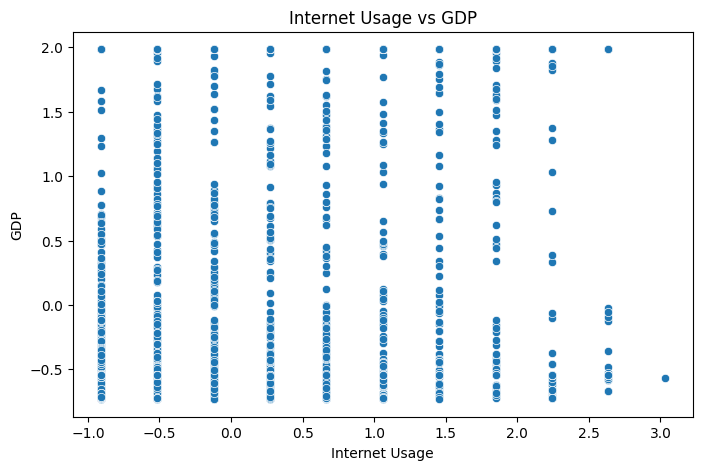

In [25]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df["Internet Usage"], y=df["GDP"])

plt.title("Internet Usage vs GDP")

plt.xlabel("Internet Usage")

plt.ylabel("GDP")

plt.show()

# Scatter Plot Analysis #
Plotted Internet Usage against GDP to explore the relationship between digital adoption and economic output.

This scatter plot shows the relationship between internet usage and GDP. The visualization suggests that countries with higher internet usage often tend to have higher GDP, indicating the importance of technological development in economic growth.

# Male vs Female Life Expectancy

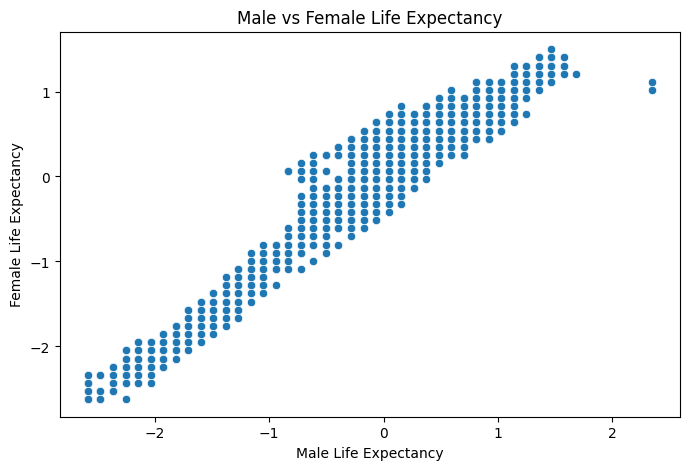

In [26]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df["Life Expectancy Male"],
                y=df["Life Expectancy Female"])

plt.title("Male vs Female Life Expectancy")

plt.xlabel("Male Life Expectancy")

plt.ylabel("Female Life Expectancy")

plt.show()

# Life Expectancy Comparison #
Created a scatter plot comparing male vs female life expectancy to visualize gender-based health outcomes.

This scatter plot compares male and female life expectancy across countries. The visualization shows that female life expectancy is generally higher than male life expectancy in most countries.

# Energy Usage vs CO2 Emissions

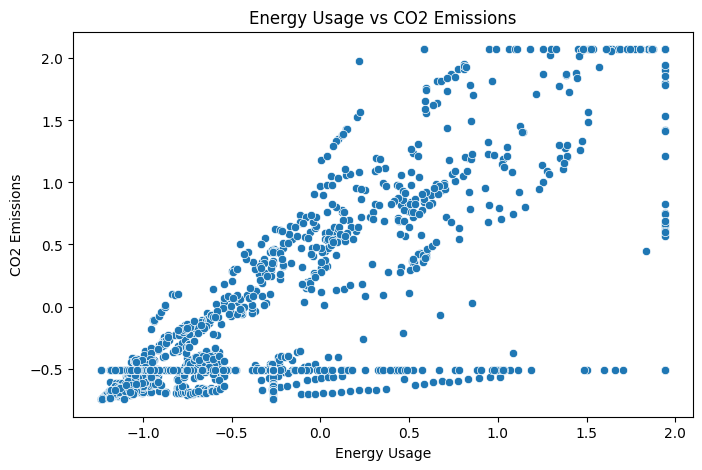

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df["Energy Usage"],
                y=df["CO2 Emissions"])

plt.title("Energy Usage vs CO2 Emissions")

plt.xlabel("Energy Usage")

plt.ylabel("CO2 Emissions")

plt.show()

# Energy vs Emissions Analysis #
Plotted a scatter plot of Energy Usage against CO₂ Emissions to examine the link between energy consumption and environmental impact.

This visualization shows the relationship between energy usage and CO₂ emissions. Countries with higher energy consumption generally produce more carbon emissions, indicating the environmental impact of industrial and economic activity.

# Population Age Distribution

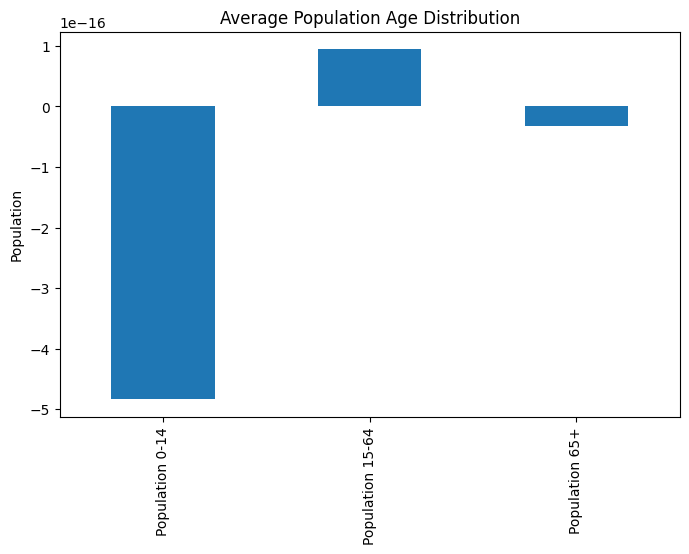

In [28]:
population = ["Population 0-14", "Population 15-64", "Population 65+"]

df[population].mean().plot(kind="bar", figsize=(8,5))

plt.title("Average Population Age Distribution")

plt.ylabel("Population")

plt.show()

# Population Age Distribution #
Plotted a bar chart of average population across age groups (0–14, 15–64, 65+) to visualize demographic structure.

This bar chart shows the average population distribution across three age groups: 0–14, 15–64, and 65+. The visualization helps understand the demographic structure of countries and indicates that the working-age population generally represents the largest group.

# Pairplot

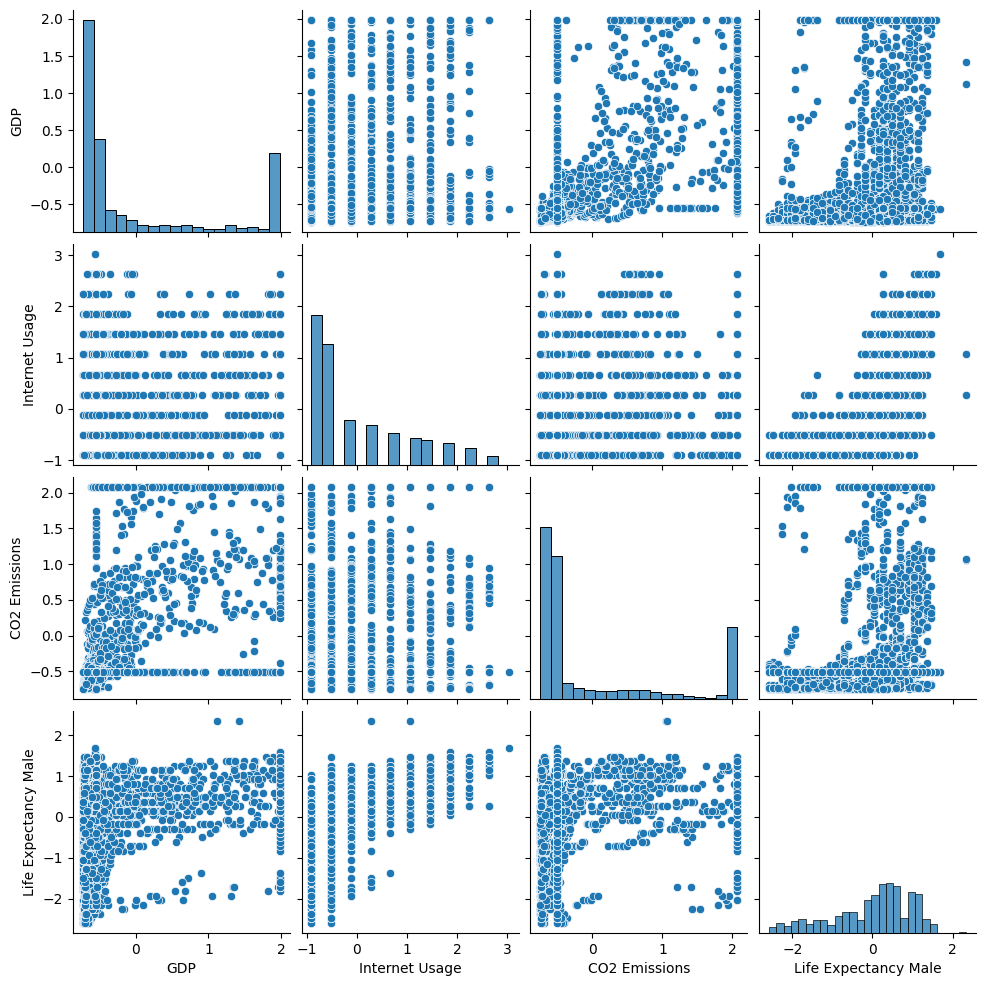

In [29]:
selected = df[["GDP",
               "Internet Usage",
               "CO2 Emissions",
               "Life Expectancy Male"]]

sns.pairplot(selected)

plt.show()

The pairplot visualizes relationships between key development indicators such as GDP, internet usage, CO₂ emissions, and life expectancy. The diagonal plots show the distribution of each variable, while the off-diagonal plots display scatter relationships between variable pairs. The visualization helps identify patterns and correlations among multiple development indicators simultaneously.

# Pairwise Relationship Analysis #
Generated a pairplot of GDP, Internet Usage, CO₂ Emissions, and Male Life Expectancy to visualize correlations and
distributions across indicators.

In [30]:
df = df.drop(['Country'], axis=1)

In [31]:
df = df.fillna(df.mean())

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# **Model Building & Model Evaluation**

# pca principal component analysis

# Import #

 # This code imports PCA for dimensionality reduction, numpy for calculations, and matplotlib for visualization.#

In [33]:
# Create PCA object to apply PCA on data
pca = PCA()

# Apply PCA on scaled data and convert it into principal components
X_pca_temp = pca.fit_transform(X_scaled)

# creates a PCA model#
It is used to reduce the number of features in the data.
Then it transforms the scaled data into principal components.

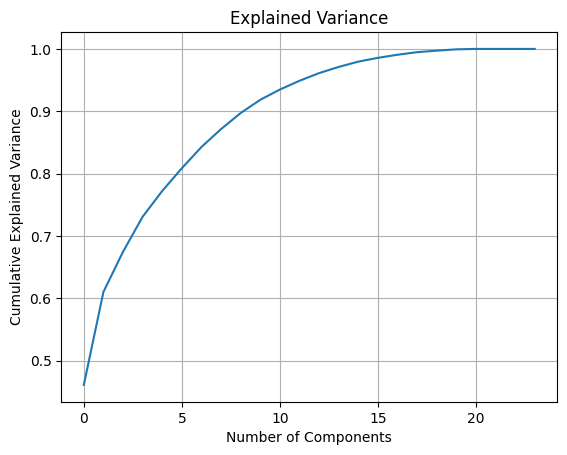

In [34]:
# Plot cumulative explained variance
plt.plot(np.cumsum(pca.explained_variance_ratio_))

# X-axis shows number of components
plt.xlabel('Number of Components')

# Y-axis shows total variance explained
plt.ylabel('Cumulative Explained Variance')

 # Title of the graph
plt.title('Explained Variance')

# Show grid for better view
plt.grid()

# Display the graph
plt.show()

 # This code creates a graph to show how much data is explained by each component #
It helps to understand how many components are needed.
The graph shows cumulative explained variance for better decision making.

In [35]:
# Create PCA model with 2 components
pca = PCA(n_components=2)

# Transform scaled data into 2 principal components
X_pca = pca.fit_transform(X_scaled)

# This code sets PCA to use 2 components #
It reduces the data into 2 new features.
Then it transforms the scaled data into these components

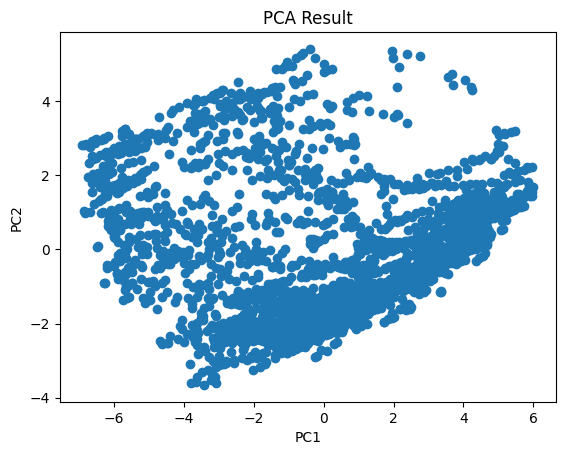

In [36]:
# Create scatter plot using PC1 and PC2
plt.scatter(X_pca[:,0], X_pca[:,1])

# X-axis shows first principal component
plt.xlabel('PC1')

# Y-axis shows second principal component
plt.ylabel('PC2')

# Title of the graph
plt.title('PCA Result')

# Display the plot
plt.show()

# This code creates a scatter plot using PCA data #
It shows the data in two dimensions using PC1 and PC2.
Each point represents one data record.
It helps to see patterns and groups in the data

In [37]:
# Print shape of transformed data
print("Shape:", X_pca.shape)

# Print variance explained by each component
print("Variance:", pca.explained_variance_ratio_)

Shape: (2704, 2)
Variance: [0.46100188 0.14913198]


# This code prints the shape of the PCA data #
It shows how many rows and columns are present.
It also prints the variance of each component.
This helps to understand how much data is captured by PCA.

# ** K-MEANS MODEL**

Partitions data into a fixed number of clusters based on similarity (distance).

In [38]:
# this code checks how clusters look for different K value
for k in [2, 3, 4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)

    print("K =", k, "→ clusters:", set(labels))

K = 2 → clusters: {np.int32(0), np.int32(1)}
K = 3 → clusters: {np.int32(0), np.int32(1), np.int32(2)}
K = 4 → clusters: {np.int32(0), np.int32(1), np.int32(2), np.int32(3)}
K = 5 → clusters: {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)}


Different values of K were tested to observe cluster formation.
K=3 was selected because it provides meaningful and interpretable clusters.

It aligns with real-world grouping of countries into developed,
developing, and underdeveloped categories.

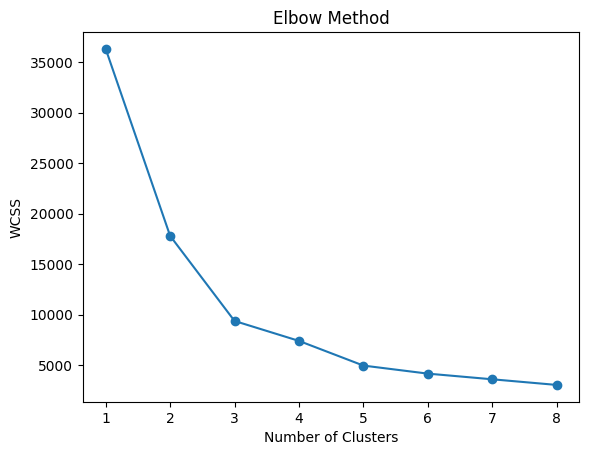

In [39]:
# Elbow Method: helps confirm optimal number of clusters
wcss = []

# try K from 1 to 8
for i in range(1, 9):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

# plot graph
plt.plot(range(1, 9), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

The elbow method graph shows a sharp decrease in WCSS from K=1 to K=3,
after which the decrease becomes gradual.

This indicates that K=3 is the optimal number of clusters,
as adding more clusters does not significantly improve the model.

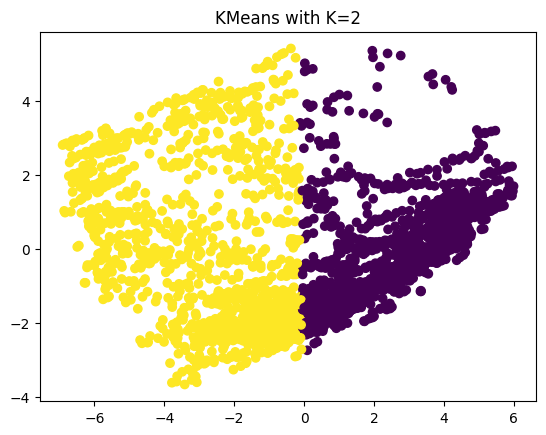

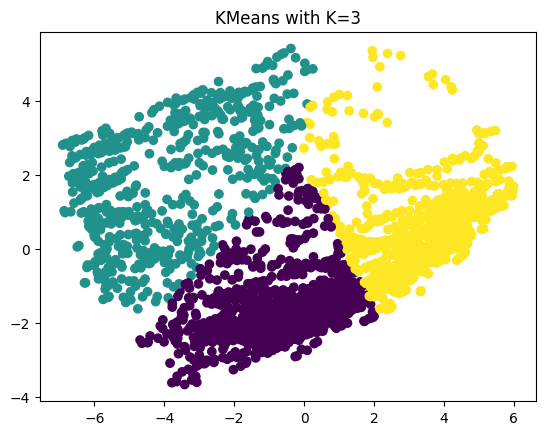

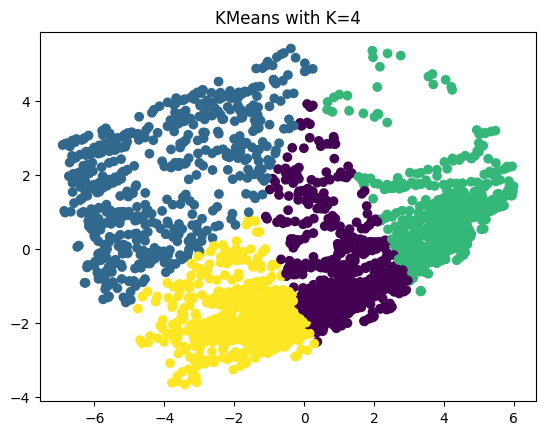

In [40]:
# visualize clusters for K = 2,3,4
for k in [2,3,4]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)

    plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
    plt.title(f"KMeans with K={k}")
    plt.show()

Different values of K (2, 3, 4) were tested and visualized.

For K=2, the clustering was too general and did not capture meaningful differences.
For K=4, the data was over-segmented into smaller clusters.

K=3 provided well-separated and balanced clusters,
making it the most meaningful choice for grouping countries.

Therefore, K=3 was selected as the optimal number of clusters.

In [41]:
# apply KMeans with selected K

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)

print("Clusters:", set(kmeans_labels))

Clusters: {np.int32(0), np.int32(1), np.int32(2)}


KMeans successfully divided the dataset into 3 clusters.
Each cluster represents a group of countries with similar characteristics.

In [42]:
df['KMeans_Cluster'] = kmeans_labels

In [43]:
cluster_summary = df.groupby('KMeans_Cluster').mean()
print(cluster_summary)

                Birth Rate  Business Tax Rate  CO2 Emissions  \
KMeans_Cluster                                                 
0                -0.521223          -0.167769      -0.338430   
1                -0.758978           0.212695       1.288638   
2                 1.124689           0.062018      -0.439164   

                Days to Start Business  Ease of Business  Energy Usage  \
KMeans_Cluster                                                           
0                            -0.149050               0.0     -0.447651   
1                            -0.353543               0.0      1.392325   
2                             0.411226               0.0     -0.375956   

                     GDP  Health Exp % GDP  Health Exp/Capita  \
KMeans_Cluster                                                  
0              -0.458691         -0.018796           0.058056   
1               1.663712          0.475290           0.996495   
2              -0.540839         -0.289412      

Cluster 1 represents developed countries, characterized by high GDP,
better healthcare, and strong economic activity.

Cluster 2 represents underdeveloped countries, with high birth rates,
low GDP, and limited healthcare resources.

Cluster 0 represents developing countries, showing moderate values across most indicators,
indicating a transitional stage of development.

# **DBSCAN**

In [44]:
# DBSCAN Clustering: groups data based on density and detects outliers
# create DBSCAN model (eps = distance, min_samples = minimum points form cluster)
dbscan = DBSCAN(eps=0.4, min_samples=5)

# fit model on PCA data and assign cluster labels
dbscan_labels = dbscan.fit_predict(X_pca)

# print clusters formed
print("DBSCAN Clusters:", set(dbscan_labels))

# count noise points (-1 = outliers)
print("Noise points:", list(dbscan_labels).count(-1))

DBSCAN Clusters: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(-1)}
Noise points: 26


DBSCAN formed several clusters and identified 26 outliers.
These outliers represent countries with unusual characteristics.

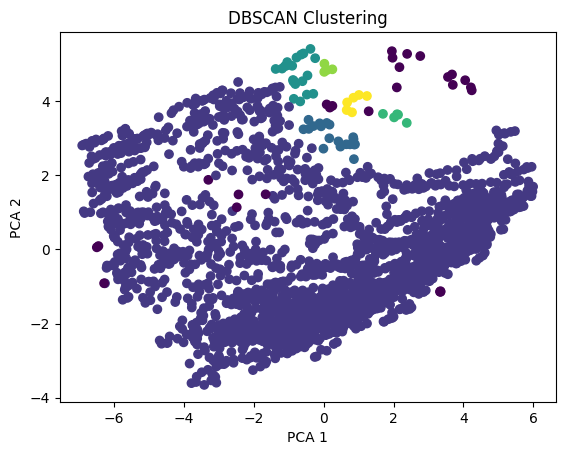

In [45]:
# visualize DBSCAN clusters
plt.scatter(X_pca[:,0], X_pca[:,1], c=dbscan_labels)
plt.title("DBSCAN Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

Different colors in the DBSCAN graph represent different clusters formed based on data density.

Points with the same color belong to the same cluster, indicating similar characteristics.
Points labeled as -1 represent outliers, which are countries with unique or extreme values.

In [46]:
# add DBSCAN cluster labels to dataset

df['DBSCAN_Cluster'] = dbscan_labels

df.head()

,Birth Rate,Business Tax Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,...,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound,KMeans_Cluster,DBSCAN_Cluster
0,-0.233864,-0.064792,1.659733,-0.151075,0.0,0.590969,-0.060055,-1.266291,-0.746454,-0.048822,...,0.0,0.384182,-0.089411,-0.684821,1.090800,0.147449,-0.754222,-0.670804,2,0
1,2.469335,-0.064792,-0.486142,-0.151075,0.0,-0.729010,-0.620533,-1.311467,-0.831569,-0.048822,...,0.0,1.696192,-1.886942,-0.978160,0.021270,-0.976530,-0.783976,-0.702383,2,0
2,1.838589,-0.064792,-0.703087,-0.151075,0.0,-1.102414,-0.703641,-0.904880,-0.847248,-0.048822,...,0.0,1.480788,-1.617312,-0.894348,-0.397993,-0.735385,-0.765161,-0.766886,2,0
3,0.396882,-0.064792,-0.630298,-0.151075,0.0,-1.112365,-0.661547,-0.724175,-0.540387,-0.048822,...,0.0,0.785618,-0.568753,-0.894348,-0.710175,-0.126393,-0.699527,-0.660053,2,0
4,2.108909,-0.064792,-0.718855,-0.151075,0.0,-0.266046,-0.700549,-0.543469,-0.853967,-0.048822,...,0.0,1.617863,-1.797065,-0.915301,-0.117991,-1.573260,-0.788789,-0.780324,2,0


DBSCAN cluster labels are added to the dataset.
Each country is now assigned to a cluster or marked as an outlier (-1).

In [47]:
# analyze DBSCAN clusters

dbscan_summary = df.groupby('DBSCAN_Cluster').mean()

print(dbscan_summary)

                Birth Rate  Business Tax Rate  CO2 Emissions  \
DBSCAN_Cluster                                                 
-1                0.795431          -0.545785       0.901842   
 0               -0.013287           0.004618      -0.047250   
 1                0.368428           0.148125       1.496139   
 2               -0.032197           0.231576       2.073597   
 3                0.865437          -0.333191       1.556103   
 4                0.216669          -0.064792       2.073597   
 5                0.441936          -0.612611       2.073597   

                Days to Start Business  Ease of Business  Energy Usage  \
DBSCAN_Cluster                                                           
-1                           -0.002076               0.0      1.307963   
 0                           -0.008153               0.0     -0.049905   
 1                            0.476863               0.0      1.541532   
 2                            0.658265               

DBSCAN identified one main cluster (Cluster 0) representing countries with average characteristics.

Clusters 1–5 represent smaller groups with specific patterns such as high economic activity or high population.

Cluster -1 represents outliers, indicating countries with extreme or unique characteristics that do not fit into any cluster.

In [48]:
# this code shows how many countries are in each cluster

print("KMeans Cluster Counts:\n", df['KMeans_Cluster'].value_counts())
print("\nDBSCAN Cluster Counts:\n", df['DBSCAN_Cluster'].value_counts())

KMeans Cluster Counts:
 KMeans_Cluster
0    1137
2     946
1     621
Name: count, dtype: int64

DBSCAN Cluster Counts:
 DBSCAN_Cluster
 0    2623
-1      26
 2      21
 1      19
 5       6
 3       5
 4       4
Name: count, dtype: int64


KMeans clustering shows a relatively balanced distribution of countries across clusters,
indicating stable and structured grouping.

In contrast, DBSCAN shows one dominant cluster containing most countries,
along with smaller clusters and a few outliers.

This highlights that KMeans enforces equal grouping,
while DBSCAN captures natural data density and identifies anomalies.

 HIERARCHICAL CLUSTERING

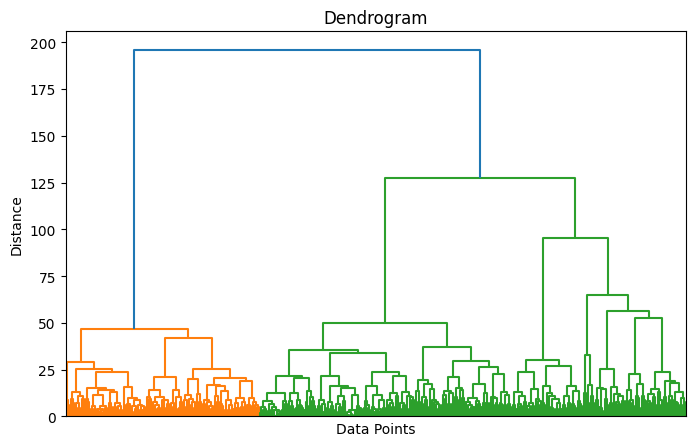

In [49]:
df_norm = StandardScaler().fit_transform(df.select_dtypes(include='number'))

plt.figure(figsize=(8,5))
sch.dendrogram(sch.linkage(df_norm, method='ward'))
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.xticks([]) 
plt.show()

The dendogram shows hierarchical merging of data pts,data divided into 3 clusters
Here thhree clusters taken is optimal balance,if 2 means it would merge very different groups,if 4 taken means it would split
naturalgroups unnesessarily.

In [50]:
df_scaled = StandardScaler().fit_transform(df.select_dtypes(include=np.number))
hc = AgglomerativeClustering(n_clusters=3)
labels = hc.fit_predict(df_scaled)

score = silhouette_score(df_scaled, labels)
print("Hierarchical Silhouette Score:", score)

Hierarchical Silhouette Score: 0.2552235974272639


Silhouette score used to evaluate clustering done